### **Corpus Selection**

#### **1. Select works in the desired format**

In [3]:
import pandas as pd

file_path = "emotion.csv"

df = pd.read_csv(file_path)

print(df.head())

     Project Name                Document Directory Global Region  \
0  TINTIN Project  ee628c6877967dd5e03e59a09a0dccb6        Africa   
1  TINTIN Project  ee628c6877967dd5e03e59a09a0dccb6        Africa   
2  TINTIN Project  ee628c6877967dd5e03e59a09a0dccb6        Africa   
3  TINTIN Project  ee628c6877967dd5e03e59a09a0dccb6        Africa   
4  TINTIN Project  ee628c6877967dd5e03e59a09a0dccb6        Africa   

  RegionSimplified  Country  Publication Date  Decade          Document Name  \
0           Africa  Algeria              2020    2020  The Legend of Tteryel   
1           Africa  Algeria              2020    2020  The Legend of Tteryel   
2           Africa  Algeria              2020    2020  The Legend of Tteryel   
3           Africa  Algeria              2020    2020  The Legend of Tteryel   
4           Africa  Algeria              2020    2020  The Legend of Tteryel   

  StyleBroad StyleDetail  ... TotalPanels MaxPagePanels Region ID Region Type  \
0      Manga       Mang

In [4]:
# Count how many works are in the whole corpus
df["Document Directory"].nunique()

1030

In [6]:
# Filter works by format
df["Format"] = df["Format"].str.title()
df["Format"] = df["Format"].str.strip()
df.groupby("Format")["Document Directory"].nunique()

Format
Anthology        206
Comic Book       324
Graphic Novel    156
Short Story      191
Webcomic         153
Name: Document Directory, dtype: int64

In [7]:
# Select works in the desired format
selected_formats = ["Anthology", "Comic Book", "Short Story"]
df_selected = df[df["Format"].isin(selected_formats)].copy()
df_selected["Format"].value_counts()

Comic Book     27279
Anthology      13115
Short Story    11306
Name: Format, dtype: int64

In [8]:
df_selected.groupby("Format")["Document Directory"].nunique()

Format
Anthology      206
Comic Book     324
Short Story    191
Name: Document Directory, dtype: int64

In [17]:
df_selected.to_csv("selected.csv", index=False)

#### **2. Subcategories**

In [18]:
df_selected = pd.read_csv("selected.csv")

In [19]:
print(df_selected.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51700 entries, 0 to 51699
Data columns (total 30 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Project Name        51700 non-null  object 
 1   Document Directory  51700 non-null  object 
 2   Global Region       51700 non-null  object 
 3   RegionSimplified    51700 non-null  object 
 4   Country             51700 non-null  object 
 5   Publication Date    51700 non-null  int64  
 6   Decade              51700 non-null  int64  
 7   Document Name       51700 non-null  object 
 8   StyleBroad          51700 non-null  object 
 9   StyleDetail         51700 non-null  object 
 10  LanguageFinal       51700 non-null  object 
 11  Genre Simplified    51700 non-null  object 
 12  Modality            51700 non-null  object 
 13  Format              51700 non-null  object 
 14  Page Number         51700 non-null  int64  
 15  PageOrdinal         51700 non-null  int64  
 16  Pane

In [20]:
df_selected.groupby("RegionSimplified")["Document Directory"]\
           .nunique()\
           .sort_values(ascending=False)

RegionSimplified
Europe               193
Africa               155
South America         95
East Asia             87
SouthCentral Asia     70
West Asia             61
North America         41
Oceania               19
Name: Document Directory, dtype: int64

#### **2.1 Genre**

In [59]:
# Count the number of books for each simplified genre
df_selected.groupby("Genre Simplified")["Document Directory"].nunique()

Genre Simplified
(blank)                  19
Action Adventure         99
Autobiography             3
Biography                 7
Childrens                 3
Comedy                    4
Drama                   139
Fantasy                 118
Historical adventure     10
Historical fiction        7
History                  11
Horror                   38
Humor                    18
Independent              21
Mythology                20
Non-fiction               3
Political                36
Romance                   7
Science fiction          46
Superhero                69
Supernatural             27
Thriller                  5
War                       6
Western                   5
Name: Document Directory, dtype: int64

In [62]:
# Count the number of books for each combination of region and simplified genre
genre_counts = (
    df_selected.groupby(["RegionSimplified", "Genre Simplified"])["Document Directory"]
    .nunique()
    .reset_index(name="count")
)

# Calculate the total number of unique documents within each region
total_by_region = genre_counts.groupby("RegionSimplified")["count"].transform("sum")

# Create a copy of the counts dataframe and compute the percentage share of each genre within its region
genre_ratio = genre_counts.copy()
genre_ratio["percentage"] = genre_ratio["count"] / total_by_region

# For each region, display the genres sorted by their proportion in descending order
for region, sub in genre_ratio.groupby("RegionSimplified"):
    print(f"\n===== {region} =====")
    print(
        sub.sort_values("percentage", ascending=False)
        [["Genre Simplified", "percentage"]]
        .assign(percentage=lambda x: x["percentage"].round(2))
    )


===== Africa =====
        Genre Simplified  percentage
2                  Drama        0.22
7              Political        0.18
9              Superhero        0.18
3                Fantasy        0.15
0                (blank)        0.08
1       Action Adventure        0.06
8        Science fiction        0.04
5                 Horror        0.03
10          Supernatural        0.03
6                  Humor        0.01
4   Historical adventure        0.01
11              Thriller        0.01

===== East Asia =====
        Genre Simplified  percentage
17               Fantasy        0.22
16                 Drama        0.20
13      Action Adventure        0.14
22             Mythology        0.14
12               (blank)        0.07
24       Science fiction        0.07
20                Horror        0.06
25             Superhero        0.03
23               Romance        0.02
14         Autobiography        0.01
15             Childrens        0.01
18  Historical adventure        

<Figure size 1200x700 with 0 Axes>

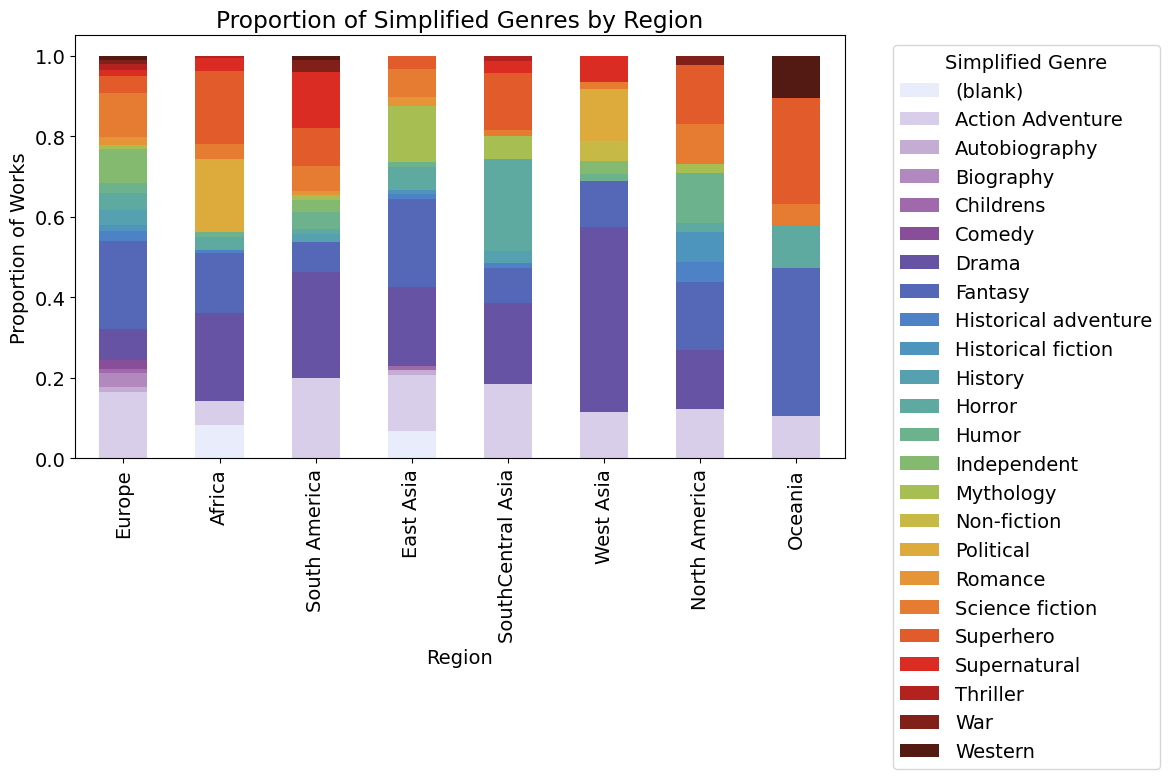

In [78]:
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

# Create colormap using the colorblind-friendly list from Paul Tol
smooth_rainbow = [
    '#E8ECFB', '#DDD8EF', '#D1C1E1', '#C3A8D1', '#B58FC2', '#A778B4',
    '#9B62A7', '#8C4E99', '#6F4C9B', '#6059A9', '#5568B8', '#4E79C5',
    '#4D8AC6', '#4E96BC', '#549EB3', '#59A5A9', '#60AB9E', '#69B190',
    '#77B77D', '#8CBC68', '#A6BE54', '#BEBC48', '#D1B541', '#DDAA3C',
    '#E49C39', '#E78C35', '#E67932', '#E4632D', '#DF4828', '#DA2222',
    '#B8221E', '#95211B', '#721E17', '#521A13'
]

cmap = LinearSegmentedColormap.from_list("paul_tol_smooth_rainbow", smooth_rainbow)

# Generate colors based on the number of genres
num_genres = genre_proportions.shape[1]
colors = [cmap(i / (num_genres - 1)) for i in range(num_genres)]

plt.figure(figsize=(12, 7))

genre_proportions.plot(
    kind="bar",
    stacked=True,
    figsize=(12, 7),
    color=colors
)

plt.title("Proportion of Simplified Genres by Region")
plt.ylabel("Proportion of Works")
plt.xlabel("Region")

plt.legend(
    title="Simplified Genre",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

#### **2.2 Style**

In [64]:
# Count the number of books for each simplified style
df_selected.groupby("StyleBroad")["Document Directory"].nunique()

StyleBroad
Alternative         28
Cartoony           140
Manga              195
RealExaggerated    235
Realistic          123
Name: Document Directory, dtype: int64

In [65]:
# Count the number of books for each combination of region and broad style category
style_counts = (
    df_selected.groupby(["RegionSimplified", "StyleBroad"])["Document Directory"]
    .nunique()
    .reset_index(name="count")
)

# Calculate the total number of unique documents within each region
total_by_region = style_counts.groupby("RegionSimplified")["count"].transform("sum")

# Create a copy of the counts dataframe and compute the percentage share of each style within its region
style_ratio = style_counts.copy()
style_ratio["percentage"] = style_ratio["count"] / total_by_region

# For each region, display the styles sorted by their proportion in descending order
for region, sub in style_ratio.groupby("RegionSimplified"):
    print(f"\n===== {region} =====")
    print(
        sub.sort_values("percentage", ascending=False)
        [["StyleBroad", "percentage"]]
        .assign(percentage=lambda x: x["percentage"].round(2))
    )


===== Africa =====
        StyleBroad  percentage
2  RealExaggerated        0.50
0         Cartoony        0.25
1            Manga        0.21
3        Realistic        0.04

===== East Asia =====
        StyleBroad  percentage
5            Manga        0.54
7        Realistic        0.21
6  RealExaggerated        0.17
4         Cartoony        0.08

===== Europe =====
         StyleBroad  percentage
11  RealExaggerated        0.28
12        Realistic        0.28
9          Cartoony        0.17
10            Manga        0.14
8       Alternative        0.12

===== North America =====
         StyleBroad  percentage
16  RealExaggerated        0.34
14         Cartoony        0.22
17        Realistic        0.22
15            Manga        0.20
13      Alternative        0.02

===== Oceania =====
         StyleBroad  percentage
19  RealExaggerated        0.47
20        Realistic        0.42
18         Cartoony        0.11

===== South America =====
         StyleBroad  percentage
22      

<Figure size 1200x700 with 0 Axes>

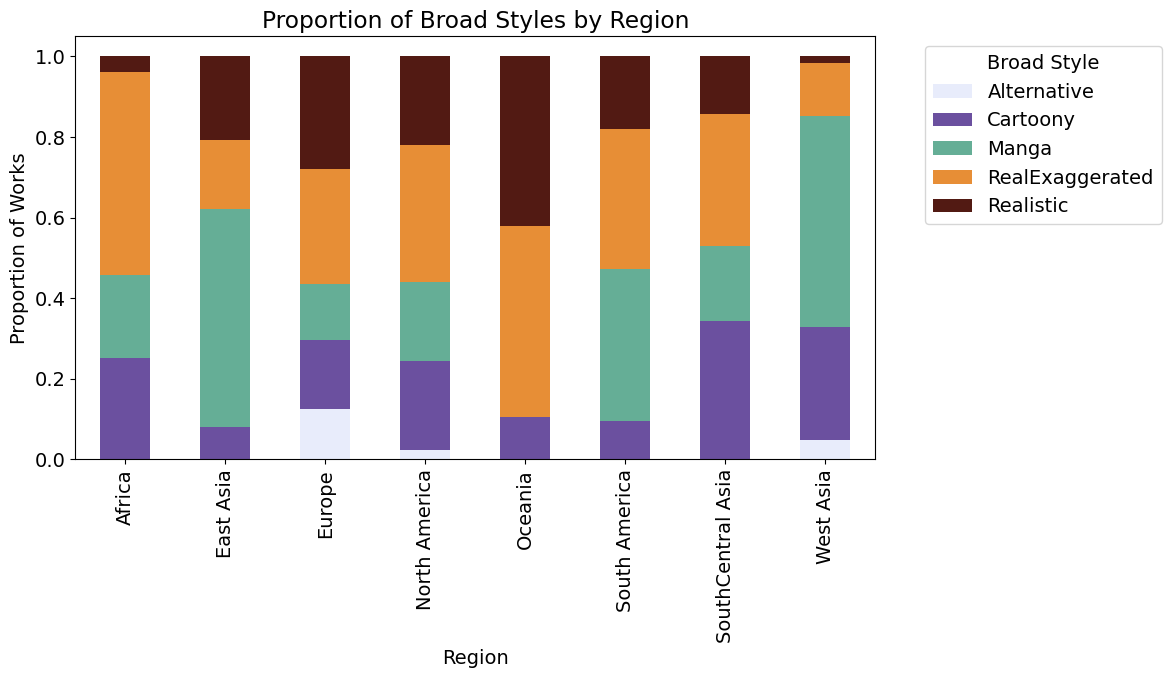

In [71]:
style_proportions = style_ratio.pivot(
    index="RegionSimplified",
    columns="StyleBroad",
    values="percentage"
)

# Create colormap using the colorblind-friendly list from Paul Tol
smooth_rainbow = [
    '#E8ECFB', '#DDD8EF', '#D1C1E1', '#C3A8D1', '#B58FC2', '#A778B4',
    '#9B62A7', '#8C4E99', '#6F4C9B', '#6059A9', '#5568B8', '#4E79C5',
    '#4D8AC6', '#4E96BC', '#549EB3', '#59A5A9', '#60AB9E', '#69B190',
    '#77B77D', '#8CBC68', '#A6BE54', '#BEBC48', '#D1B541', '#DDAA3C',
    '#E49C39', '#E78C35', '#E67932', '#E4632D', '#DF4828', '#DA2222',
    '#B8221E', '#95211B', '#721E17', '#521A13'
]

cmap = LinearSegmentedColormap.from_list("paul_tol_smooth_rainbow", smooth_rainbow)

# Generate colors based on the number of style categories
num_styles = style_proportions.shape[1]
colors = [cmap(i / (num_styles - 1)) for i in range(num_styles)]

plt.figure(figsize=(12, 7))

style_proportions.plot(
    kind="bar",
    stacked=True,
    figsize=(12, 7),
    color=colors
)

plt.title("Proportion of Broad Styles by Region")
plt.ylabel("Proportion of Works")
plt.xlabel("Region")

plt.legend(
    title="Broad Style",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

#### **2.3 Language**

In [72]:
# Count the number of books for each simplified style
df_selected.groupby("LanguageFinal")["Document Directory"].nunique()

LanguageFinal
Albanian              1
Arabic               68
Armenian             11
Belarusian            5
Bengali              20
Bulgarian             7
Burmese               5
Catalan               9
Croatian              6
Czech                 2
Danish                1
Dutch                 3
English             211
French               50
Georgian              1
German                7
Greek                 3
Guarani               2
Hindi                 2
Hungarian             7
Icelandic            16
Indonesian           12
Italian              16
Japanese             10
Javanese              7
Kazakh                2
Korean                1
Kyrgyz                1
Lithuanian            2
Malagasy              2
Mandarin Chinese     10
Montenegrin           1
Nepali                2
Persian               5
Polish                9
Portuguese           15
Romanian             11
Russian              14
Serbian              16
Slovak               10
Slovenian             2
So

In [ ]:
# Count the number of books for each combination of region and broad style category
style_counts = (
    df_selected.groupby(["RegionSimplified", "StyleBroad"])["Document Directory"]
    .nunique()
    .reset_index(name="count")
)

# Calculate the total number of unique documents within each region
total_by_region = style_counts.groupby("RegionSimplified")["count"].transform("sum")

# Create a copy of the counts dataframe and compute the percentage share of each style within its region
style_ratio = style_counts.copy()
style_ratio["percentage"] = style_ratio["count"] / total_by_region

# For each region, display the styles sorted by their proportion in descending order
for region, sub in style_ratio.groupby("RegionSimplified"):
    print(f"\n===== {region} =====")
    print(
        sub.sort_values("percentage", ascending=False)
        [["StyleBroad", "percentage"]]
        .assign(percentage=lambda x: x["percentage"].round(2))
    )

In [73]:
# Count the number of books for each combination of region and final language
language_counts = (
    df_selected.groupby(["RegionSimplified", "LanguageFinal"])["Document Directory"]
    .nunique()
    .reset_index(name="count")
)

# Calculate the total number of unique documents within each region
total_by_region = language_counts.groupby("RegionSimplified")["count"].transform("sum")

# Create a copy of the counts dataframe and compute the percentage share of each language within its region
language_ratio = language_counts.copy()
language_ratio["percentage"] = language_ratio["count"] / total_by_region

# For each region, display the languages sorted by their proportion in descending order
for region, sub in language_ratio.groupby("RegionSimplified"):
    print(f"\n===== {region} =====")
    print(
        sub.sort_values("percentage", ascending=False)
        [["LanguageFinal", "percentage"]]
        .assign(percentage=lambda x: x["percentage"].round(2))
    )


===== Africa =====
  LanguageFinal  percentage
1       English        0.52
0        Arabic        0.23
2        French        0.20
4    Portuguese        0.02
6       Swahili        0.02
3      Malagasy        0.01
5        Somali        0.01

===== East Asia =====
       LanguageFinal  percentage
8            English        0.22
9         Indonesian        0.14
15              Thai        0.14
10          Japanese        0.11
13  Mandarin Chinese        0.11
16        Vietnamese        0.10
11          Javanese        0.08
7            Burmese        0.06
14           Tagalog        0.02
12            Korean        0.01

===== Europe =====
   LanguageFinal  percentage
25       English        0.15
30     Icelandic        0.08
37       Serbian        0.08
31       Italian        0.08
36       Russian        0.07
35      Romanian        0.06
38        Slovak        0.05
34        Polish        0.05
20       Catalan        0.05
26        French        0.05
19     Bulgarian        0.04
27

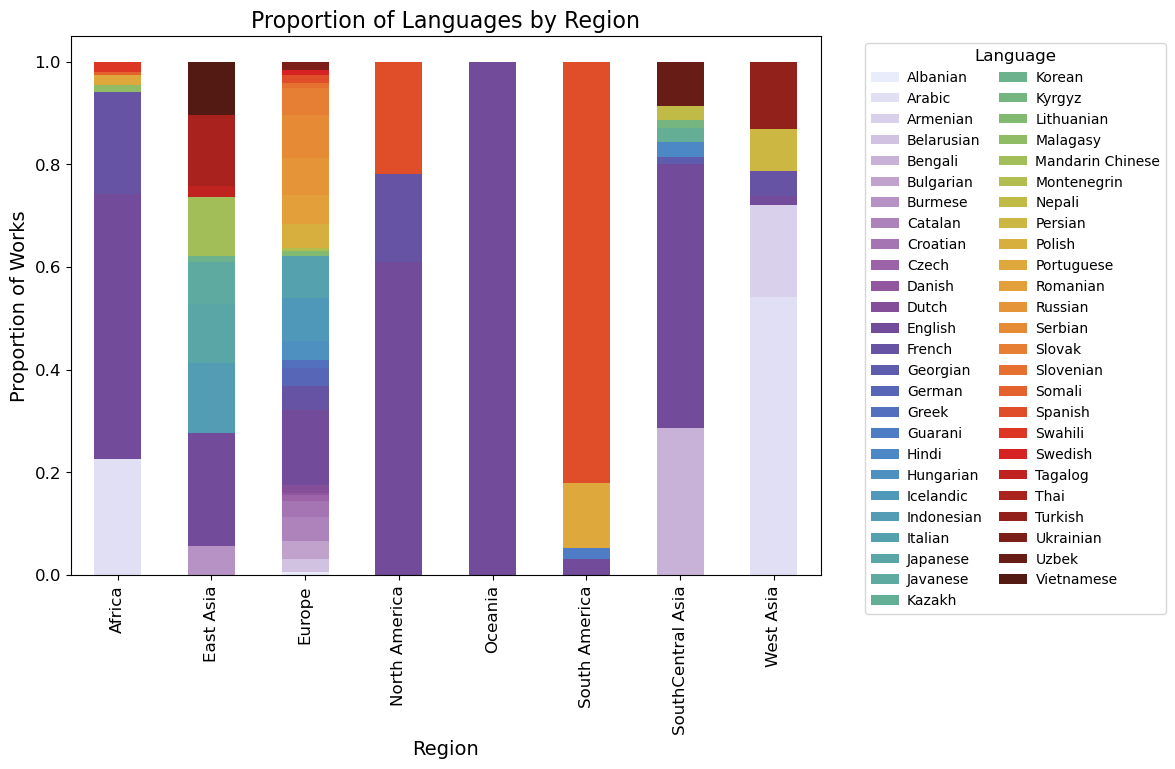

In [76]:
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

# Create pivot table for plotting proportions by language
language_proportions = language_ratio.pivot(
    index="RegionSimplified",
    columns="LanguageFinal",
    values="percentage"
)

# Create colormap using the colorblind-friendly list from Paul Tol
smooth_rainbow = [
    '#E8ECFB', '#DDD8EF', '#D1C1E1', '#C3A8D1', '#B58FC2', '#A778B4',
    '#9B62A7', '#8C4E99', '#6F4C9B', '#6059A9', '#5568B8', '#4E79C5',
    '#4D8AC6', '#4E96BC', '#549EB3', '#59A5A9', '#60AB9E', '#69B190',
    '#77B77D', '#8CBC68', '#A6BE54', '#BEBC48', '#D1B541', '#DDAA3C',
    '#E49C39', '#E78C35', '#E67932', '#E4632D', '#DF4828', '#DA2222',
    '#B8221E', '#95211B', '#721E17', '#521A13'
]

# Build the colormap
cmap = LinearSegmentedColormap.from_list("paul_tol_smooth_rainbow", smooth_rainbow)

# Generate colors based on the number of language categories
num_languages = language_proportions.shape[1]
colors = [cmap(i / (num_languages - 1)) for i in range(num_languages)]

# Create figure and axes explicitly
fig, ax = plt.subplots(figsize=(12, 7))

# Plot stacked bar chart
language_proportions.plot(
    kind="bar",
    stacked=True,
    ax=ax,
    color=colors
)

# Set labels and title
ax.set_title("Proportion of Languages by Region", fontsize=16)
ax.set_ylabel("Proportion of Works", fontsize=14)
ax.set_xlabel("Region", fontsize=14)

# Adjust tick label size
ax.tick_params(axis='x', labelsize=12)
ax.tick_params(axis='y', labelsize=12)

# Display legend in two columns to reduce height
ax.legend(
    title="Language",
    bbox_to_anchor=(1.05, 1),
    loc="upper left",
    ncol=2,
    fontsize=10,
    title_fontsize=12,
    columnspacing=1.2,
    handletextpad=0.6
)

# Adjust layout so legend fits nicely
plt.subplots_adjust(right=0.75)

plt.show()

#### **2.4 Country**

In [91]:
df_selected["Country"] = df_selected["Country"].replace(
    r"Canada-Qu.*", "Canada-Québec", regex=True
)

In [92]:
# Count the number of books for each simplified style
df_selected.groupby("Country")["Document Directory"].nunique()

Country
Albania       1
Algeria       1
Angola        3
Argentina    10
Armenia      11
             ..
Venezuela     1
Vietnam       9
Yemen         1
Zambia        4
Zimbabwe     17
Name: Document Directory, Length: 119, dtype: int64

In [93]:
# Count the number of books for each combination of region and country
country_counts = (
    df_selected.groupby(["RegionSimplified", "Country"])["Document Directory"]
    .nunique()
    .reset_index(name="count")
)

# Calculate the total number of unique documents within each region
total_by_region = country_counts.groupby("RegionSimplified")["count"].transform("sum")

# Create a copy of the counts dataframe and compute the percentage share of each country within its region
country_ratio = country_counts.copy()
country_ratio["percentage"] = country_ratio["count"] / total_by_region

# For each region, display the countries sorted by their proportion in descending order
for region, sub in country_ratio.groupby("RegionSimplified"):
    print(f"\n===== {region} =====")
    print(
        sub.sort_values("percentage", ascending=False)
        [["Country", "percentage"]]
        .assign(percentage=lambda x: x["percentage"].round(2))
    )


===== Africa =====
                             Country  percentage
29                          Zimbabwe        0.11
7                              Egypt        0.06
17                           Nigeria        0.06
21                      South Africa        0.06
11                             Kenya        0.06
15                           Morocco        0.06
9                              Ghana        0.05
12                             Libya        0.05
19                           Senegal        0.05
26                           Tunisia        0.05
6   Democratic Republic of the Congo        0.04
5                           Cameroon        0.04
10                       Ivory Coast        0.03
24                          Tanzania        0.03
23                             Sudan        0.03
8                           Ethiopia        0.03
28                            Zambia        0.03
27                            Uganda        0.02
25                              Togo        0.02


In [94]:
# Keep only top 10 countries per region, others merged as "Other"
top_n = 10

def merge_small_countries(df):
    df = df.sort_values("percentage", ascending=False)
    top = df.head(top_n)
    others = df.iloc[top_n:]

    if not others.empty:
        other_row = pd.DataFrame({
            "RegionSimplified": [df["RegionSimplified"].iloc[0]],
            "Country": ["Other"],
            "percentage": [others["percentage"].sum()]
        })
        return pd.concat([top, other_row], ignore_index=True)
    else:
        return top

country_ratio_reduced = (
    country_ratio.groupby("RegionSimplified", group_keys=False)
    .apply(merge_small_countries)
)

In [95]:
country_proportions = country_ratio_reduced.pivot(
    index="RegionSimplified",
    columns="Country",
    values="percentage"
)

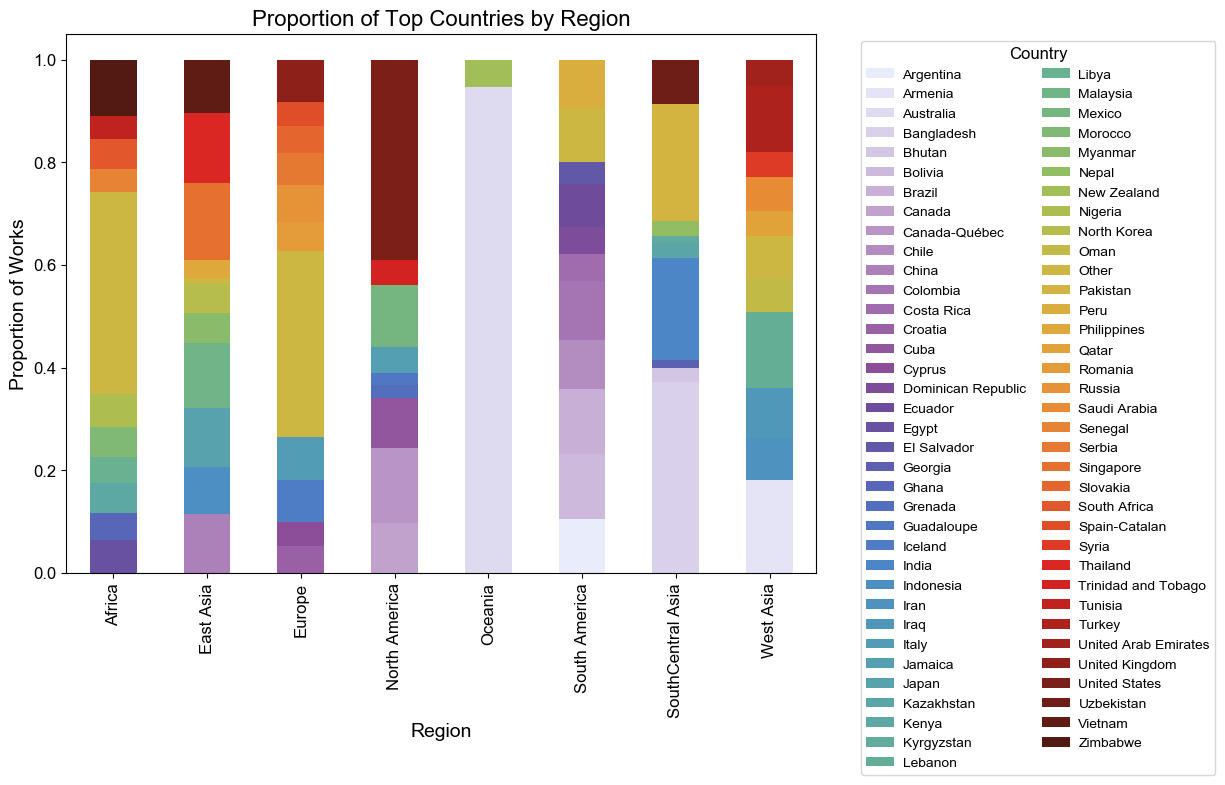

In [96]:
# Create colormap using the colorblind-friendly list from Paul Tol
smooth_rainbow = [
    '#E8ECFB', '#DDD8EF', '#D1C1E1', '#C3A8D1', '#B58FC2', '#A778B4',
    '#9B62A7', '#8C4E99', '#6F4C9B', '#6059A9', '#5568B8', '#4E79C5',
    '#4D8AC6', '#4E96BC', '#549EB3', '#59A5A9', '#60AB9E', '#69B190',
    '#77B77D', '#8CBC68', '#A6BE54', '#BEBC48', '#D1B541', '#DDAA3C',
    '#E49C39', '#E78C35', '#E67932', '#E4632D', '#DF4828', '#DA2222',
    '#B8221E', '#95211B', '#721E17', '#521A13'
]

cmap = LinearSegmentedColormap.from_list("paul_tol_smooth_rainbow", smooth_rainbow)

# Generate colors based on number of displayed countries
num_countries = country_proportions.shape[1]
colors = [cmap(i / (num_countries - 1)) for i in range(num_countries)]

fig, ax = plt.subplots(figsize=(12, 7))

country_proportions.plot(
    kind="bar",
    stacked=True,
    ax=ax,
    color=colors
)

ax.set_title("Proportion of Top Countries by Region", fontsize=16)
ax.set_ylabel("Proportion of Works", fontsize=14)
ax.set_xlabel("Region", fontsize=14)

ax.tick_params(axis='x', labelsize=12)
ax.tick_params(axis='y', labelsize=12)

ax.legend(
    title="Country",
    bbox_to_anchor=(1.05, 1),
    loc="upper left",
    ncol=2,
    fontsize=10,
    title_fontsize=12,
    columnspacing=1.2,
    handletextpad=0.6
)

plt.subplots_adjust(right=0.75)
plt.show()

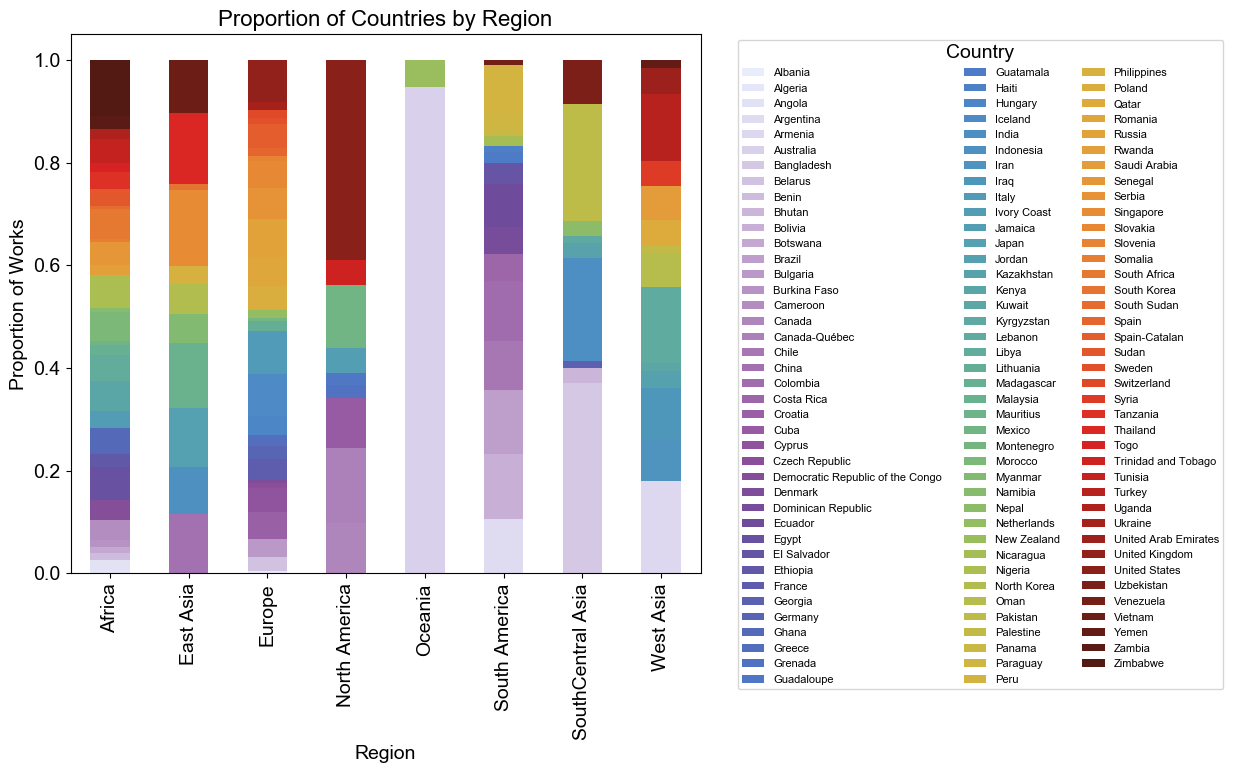

In [101]:
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

# Create pivot table for all countries (no filtering)
country_proportions = country_ratio.pivot(
    index="RegionSimplified",
    columns="Country",
    values="percentage"
)

# Create colormap
smooth_rainbow = [
    '#E8ECFB', '#DDD8EF', '#D1C1E1', '#C3A8D1', '#B58FC2', '#A778B4',
    '#9B62A7', '#8C4E99', '#6F4C9B', '#6059A9', '#5568B8', '#4E79C5',
    '#4D8AC6', '#4E96BC', '#549EB3', '#59A5A9', '#60AB9E', '#69B190',
    '#77B77D', '#8CBC68', '#A6BE54', '#BEBC48', '#D1B541', '#DDAA3C',
    '#E49C39', '#E78C35', '#E67932', '#E4632D', '#DF4828', '#DA2222',
    '#B8221E', '#95211B', '#721E17', '#521A13'
]

cmap = LinearSegmentedColormap.from_list("paul_tol_smooth_rainbow", smooth_rainbow)

# Generate colors for all countries
num_countries = country_proportions.shape[1]
colors = [cmap(i / (num_countries - 1)) for i in range(num_countries)]

fig, ax = plt.subplots(figsize=(12, 7))

country_proportions.plot(
    kind="bar",
    stacked=True,
    ax=ax,
    color=colors
)

ax.set_title("Proportion of Countries by Region", fontsize=16)
ax.set_ylabel("Proportion of Works", fontsize=14)
ax.set_xlabel("Region", fontsize=14)

ax.legend(
    title="Country",
    bbox_to_anchor=(1.05, 1),
    loc="upper left",
    ncol=3,
    fontsize=8
)

plt.subplots_adjust(right=0.65)
plt.show()

#### **2.5 Annotator**

In [102]:
# Count the number of books for each annotator
df_selected.groupby("Annotator")["Document Directory"].nunique()

Annotator
JB        134
JW        122
LZ        103
OTHERS    117
SD         90
XZ        155
Name: Document Directory, dtype: int64

In [103]:
# Count the number of books for each combination of region and annotator
annotator_counts = (
    df_selected.groupby(["RegionSimplified", "Annotator"])["Document Directory"]
    .nunique()
    .reset_index(name="count")
)

# Calculate the total number of unique documents within each region
total_by_region = annotator_counts.groupby("RegionSimplified")["count"].transform("sum")

# Create a copy of the counts dataframe and compute the percentage share of each annotator within its region
annotator_ratio = annotator_counts.copy()
annotator_ratio["percentage"] = annotator_ratio["count"] / total_by_region

# For each region, display the annotators sorted by their proportion in descending order
for region, sub in annotator_ratio.groupby("RegionSimplified"):
    print(f"\n===== {region} =====")
    print(
        sub.sort_values("percentage", ascending=False)
        [["Annotator", "percentage"]]
        .assign(percentage=lambda x: x["percentage"].round(2))
    )


===== Africa =====
  Annotator  percentage
0        JB        0.24
2        LZ        0.21
5        XZ        0.19
1        JW        0.16
3    OTHERS        0.10
4        SD        0.09

===== East Asia =====
   Annotator  percentage
9     OTHERS        0.28
7         JW        0.21
11        XZ        0.18
6         JB        0.14
10        SD        0.10
8         LZ        0.09

===== Europe =====
   Annotator  percentage
17        XZ        0.22
16        SD        0.17
12        JB        0.16
15    OTHERS        0.16
14        LZ        0.15
13        JW        0.13

===== North America =====
   Annotator  percentage
19        JW        0.34
21    OTHERS        0.20
20        LZ        0.15
23        XZ        0.12
18        JB        0.10
22        SD        0.10

===== Oceania =====
   Annotator  percentage
27    OTHERS        0.37
28        SD        0.26
24        JB        0.16
29        XZ        0.11
25        JW        0.05
26        LZ        0.05

===== South America 

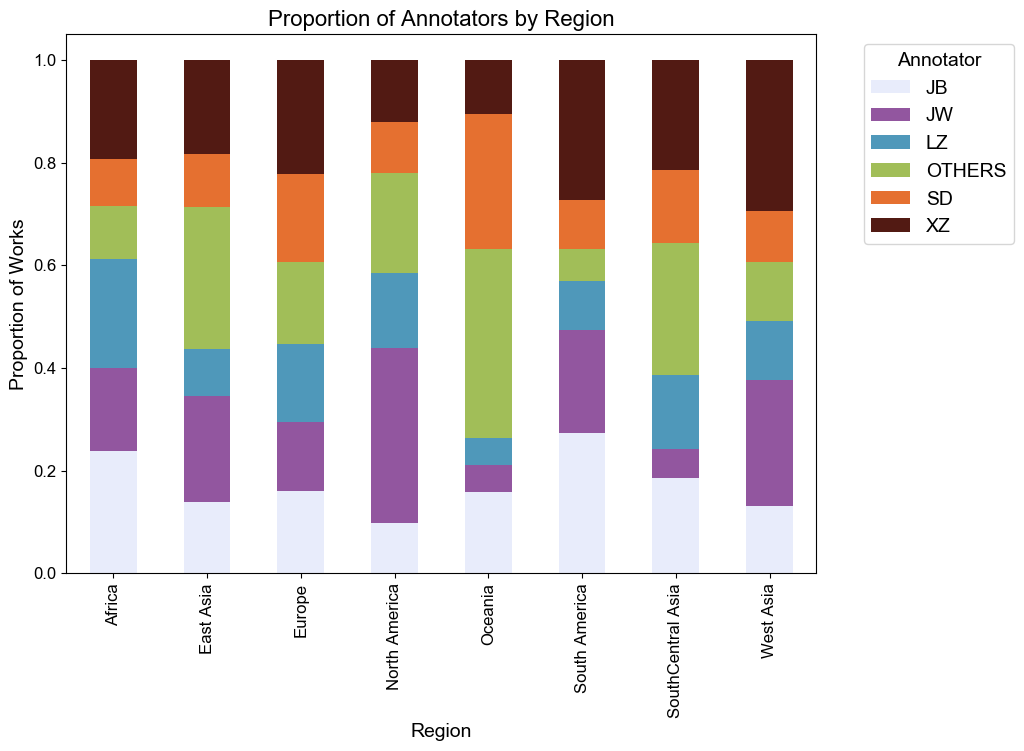

In [105]:
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

# Create pivot table for plotting proportions by annotator
annotator_proportions = annotator_ratio.pivot(
    index="RegionSimplified",
    columns="Annotator",
    values="percentage"
)

# Create colormap using the colorblind-friendly list from Paul Tol
smooth_rainbow = [
    '#E8ECFB', '#DDD8EF', '#D1C1E1', '#C3A8D1', '#B58FC2', '#A778B4',
    '#9B62A7', '#8C4E99', '#6F4C9B', '#6059A9', '#5568B8', '#4E79C5',
    '#4D8AC6', '#4E96BC', '#549EB3', '#59A5A9', '#60AB9E', '#69B190',
    '#77B77D', '#8CBC68', '#A6BE54', '#BEBC48', '#D1B541', '#DDAA3C',
    '#E49C39', '#E78C35', '#E67932', '#E4632D', '#DF4828', '#DA2222',
    '#B8221E', '#95211B', '#721E17', '#521A13'
]

cmap = LinearSegmentedColormap.from_list("paul_tol_smooth_rainbow", smooth_rainbow)

# Generate colors based on the number of annotators
num_annotators = annotator_proportions.shape[1]
colors = [cmap(i / (num_annotators - 1)) for i in range(num_annotators)]

# Create figure and axes
fig, ax = plt.subplots(figsize=(12, 7))

# Plot stacked bar chart
annotator_proportions.plot(
    kind="bar",
    stacked=True,
    ax=ax,
    color=colors
)

# Set labels and title
ax.set_title("Proportion of Annotators by Region", fontsize=16)
ax.set_ylabel("Proportion of Works", fontsize=14)
ax.set_xlabel("Region", fontsize=14)

# Adjust tick label size
ax.tick_params(axis='x', labelsize=12)
ax.tick_params(axis='y', labelsize=12)

# Display legend
ax.legend(
    title="Annotator",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.subplots_adjust(right=0.75)
plt.show()